# Tanzania Climate Data Analysis (2015–2026)

## Objective
This notebook analyzes climate data to identify trends and patterns.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading

The dataset is loaded from a local CSV file. A new column is added to indicate the country for easier identification during analysis.

In [2]:
df = pd.read_csv("../data/tanzania.csv")
df["Country"] = "Tanzania"

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania


## Date Conversion

The dataset provides YEAR and DOY (Day of Year). These are combined to create a proper datetime column, which is necessary for time series analysis. A Month column is also extracted for seasonal analysis.

In [3]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

df[["YEAR", "DOY", "Date", "Month"]].head()

,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


## Handling Missing Values

The dataset may contain -999 values, which represent missing or invalid data from the source. These are replaced with NaN to avoid distortion in statistical analysis.

In [4]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania,2026-03-27,3
4104,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania,2026-03-28,3
4105,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania,2026-03-29,3
4106,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,Tanzania,2026-03-30,3


## Duplicate Records

We check for duplicate rows in the dataset to ensure data integrity.

In [5]:
duplicates = df.duplicated().sum()
duplicates

df.drop_duplicates(inplace=True)


duplicate rows were detected and removed.

## Summary Statistics

Basic descriptive statistics are computed to understand the distribution of climate variables such as temperature, precipitation, and humidity.

In [6]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


### Interpretation

- The mean temperature (T2M) indicates generally mild to warm conditions.
- The maximum temperature (T2M_MAX) shows occasional high-temperature extremes, which may indicate heat stress periods.
- Precipitation (PRECTOTCORR) appears highly variable, suggesting seasonal rainfall patterns.
- Relative humidity (RH2M) values suggest moderate atmospheric moisture levels.

## Missing Value Analysis

We evaluate the number and percentage of missing values in each column to assess data quality.

In [7]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": missing_percent
})

,Missing Values,Percentage (%)
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


Columns with more than 5% missing values may require careful handling, such as imputation or exclusion, depending on their importance to the analysis. We have no missing values here.

## Outlier Detection

Z-scores are used to identify extreme values in selected climate variables. Observations with absolute Z-score greater than 3 are considered potential outliers.

In [8]:
import scipy
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(df[cols].apply(zscore))

outliers = (z_scores > 3).sum()
outliers

T2M             1
T2M_MAX         2
T2M_MIN         4
PRECTOTCORR    81
RH2M            2
WS2M            8
WS2M_MAX        4
dtype: int64

### Outlier Analysis Interpretation

Outlier analysis indicates that precipitation contains the highest number of extreme values, reflecting frequent intense rainfall events.
Wind speed shows a moderate number of outliers, suggesting occasional strong wind conditions.
Temperature and humidity exhibit very few outliers, indicating stable and consistent patterns.
These outliers are retained as they likely represent real climatic extremes rather than errors.

## Handling Missing Values

Missing values are handled using forward-fill for continuous weather variables. Rows with excessive missing data may be dropped to maintain data quality.

In [9]:
##df.fillna(method='ffill', inplace=True)
df.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania,2026-03-27,3
4104,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania,2026-03-28,3
4105,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania,2026-03-29,3
4106,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,Tanzania,2026-03-30,3


Forward-fill is applied to preserve temporal continuity in the dataset. This approach assumes that short gaps in measurements can be approximated using previous observations.

Rows with excessive missing values are removed to avoid unreliable analysis.

In [10]:
df.to_csv("../data/tanzania_clean.csv", index=False)

The cleaned dataset is saved for further analysis and cross-country comparison.

## Temperature Trend Analysis

We analyze monthly average temperature (T2M) over time to identify long-term trends and seasonal patterns.

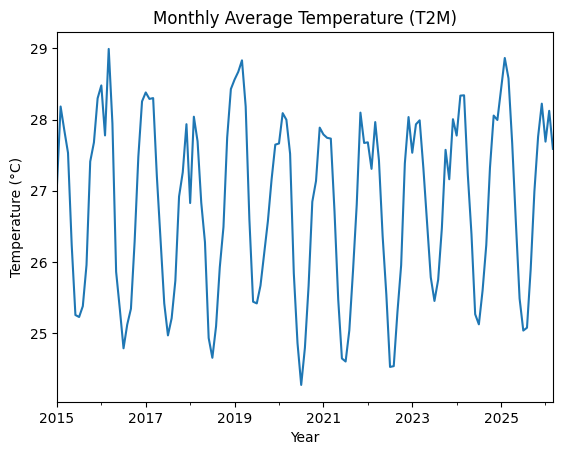

In [11]:
# Create a time-indexed DataFrame
df_time = df.set_index("Date")

# Monthly average temperature
monthly_temp = df_time["T2M"].resample("ME").mean()

# Plot
plt.figure()
monthly_temp.plot()
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.show()

### Temperature Trend Interpretation

The temperature trend shows consistent seasonal cycles with relatively small variation throughout the year.
Temperatures remain within a narrow range, reflecting a stable and moderate tropical climate.
There is no significant long-term increase or decrease, indicating overall temperature stability over time.

## Seasonal Temperature Pattern

To better understand seasonal behavior, we examine the average temperature for each month across all years.

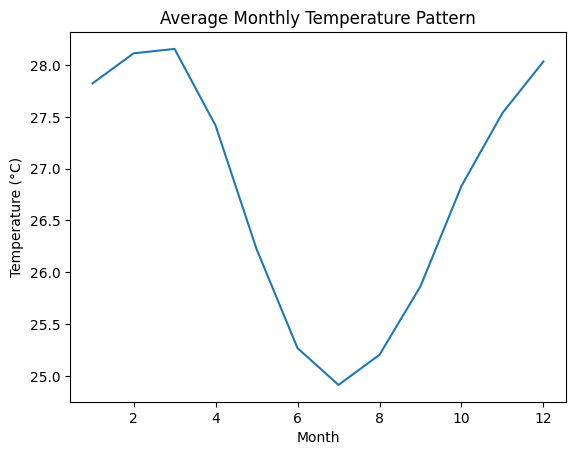

In [12]:
monthly_temp_pattern = df.groupby("Month")["T2M"].mean()

plt.figure()
monthly_temp_pattern.plot()
plt.title("Average Monthly Temperature Pattern")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

### Seasonal Temperature Pattern Interpretation

The seasonal temperature pattern shows a smooth and moderate variation across the year, with temperatures peaking in the early months and reaching their lowest in the middle of the year.
This indicates a tropical climate with mild seasonal differences rather than extreme temperature shifts.
Such a pattern reflects the influence of consistent solar radiation near the equator.

## Precipitation Analysis

We examine monthly total precipitation to identify rainfall patterns and seasonal peaks.

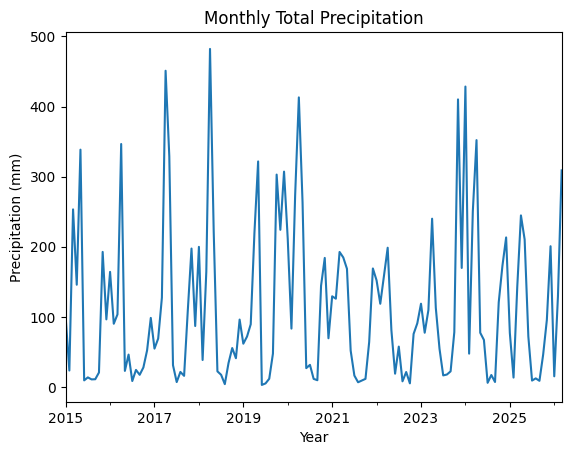

In [13]:
monthly_rain = df_time["PRECTOTCORR"].resample("ME").sum()

plt.figure()
monthly_rain.plot()
plt.title("Monthly Total Precipitation")
plt.xlabel("Year")
plt.ylabel("Precipitation (mm)")
plt.show()

### Precipitation Trend Interpretation

The rainfall trend shows high variability, with frequent sharp spikes in precipitation over time.
Rainfall is not evenly distributed and fluctuates significantly between months and years.
This indicates the presence of intermittent heavy rainfall events rather than consistent precipitation.

## Seasonal Precipitation Pattern

We examine the average precipitation for each month to better understand the timing and concentration of rainy seasons.

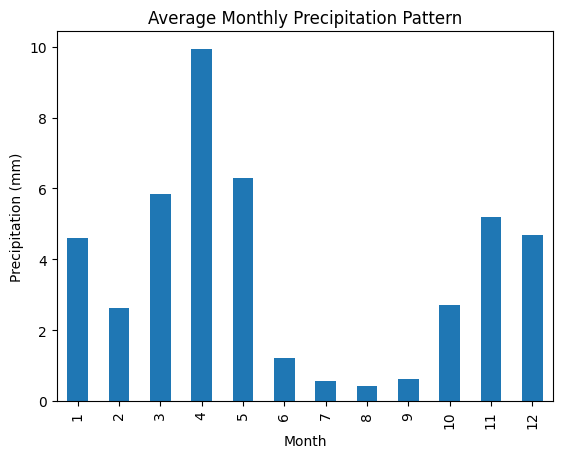

In [14]:
monthly_rain_pattern = df.groupby("Month")["PRECTOTCORR"].mean()

plt.figure()
monthly_rain_pattern.plot(kind="bar")
plt.title("Average Monthly Precipitation Pattern")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.show()

### Seasonal Precipitation Pattern Interpretation

The precipitation pattern shows a bimodal distribution, with two distinct rainy seasons occurring during the year.
The primary rainy season occurs between March and May, while a secondary, shorter rainy period appears around November and December.
Between these periods, rainfall is minimal, indicating clear wet and dry seasons typical of equatorial climates.

## Correlation Analysis

We examine relationships between key climate variables using a correlation matrix. This helps identify how different environmental factors interact with each other.

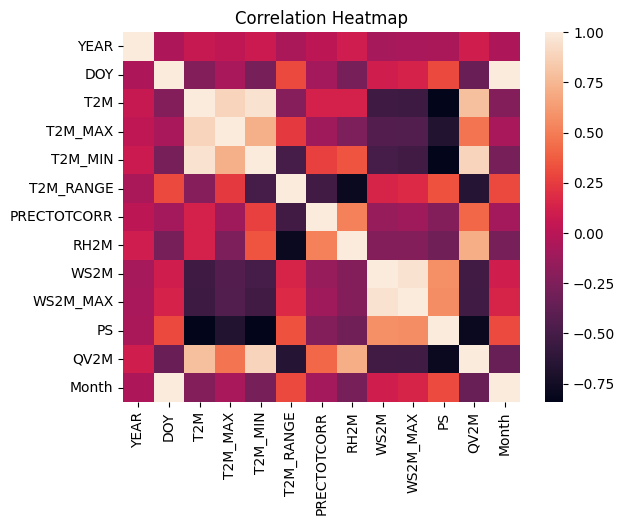

In [15]:
corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=False)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Heatmap Interpretation

The heatmap reveals strong positive correlations among temperature variables, indicating consistent temperature behavior.
A negative relationship exists between temperature and humidity, suggesting slightly drier conditions at higher temperatures.
Precipitation shows a positive correlation with humidity, emphasizing the importance of atmospheric moisture.
Other variables, such as wind speed, exhibit relatively weak relationships.

## Variable Relationships

Scatter plots are used to further explore relationships between key variables identified in the correlation analysis.

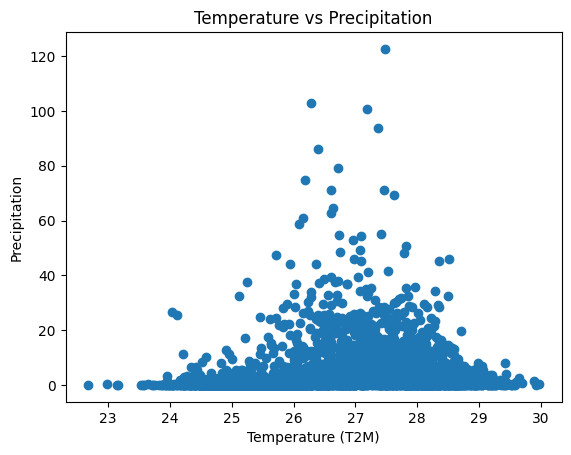

In [16]:
plt.figure()
plt.scatter(df["T2M"], df["PRECTOTCORR"])
plt.xlabel("Temperature (T2M)")
plt.ylabel("Precipitation")
plt.title("Temperature vs Precipitation")
plt.show()

### Temperature vs Precipitation Interpretation

The relationship between temperature and precipitation is weak and non-linear.
Rainfall tends to occur within a moderate temperature range, while very high or low temperatures are associated with reduced precipitation.
This indicates that temperature alone is not a strong predictor of rainfall in this region.

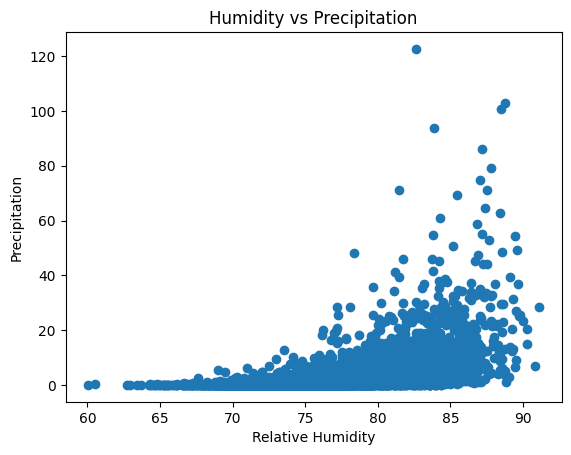

In [17]:
plt.figure()
plt.scatter(df["RH2M"], df["PRECTOTCORR"])
plt.xlabel("Relative Humidity")
plt.ylabel("Precipitation")
plt.title("Humidity vs Precipitation")
plt.show()

### Humidity vs Precipitation Interpretation

The scatter plot shows a positive relationship between humidity and precipitation, where higher humidity levels generally correspond to increased rainfall.
However, the relationship is not perfectly consistent, as some high humidity conditions do not result in precipitation.
This suggests that while moisture is necessary, additional factors influence rainfall occurrence.

## Precipitation Distribution Analysis

To better understand the distribution of precipitation, a histogram is plotted. Since precipitation data is typically highly skewed, a logarithmic transformation is applied to improve visualization and highlight underlying patterns.

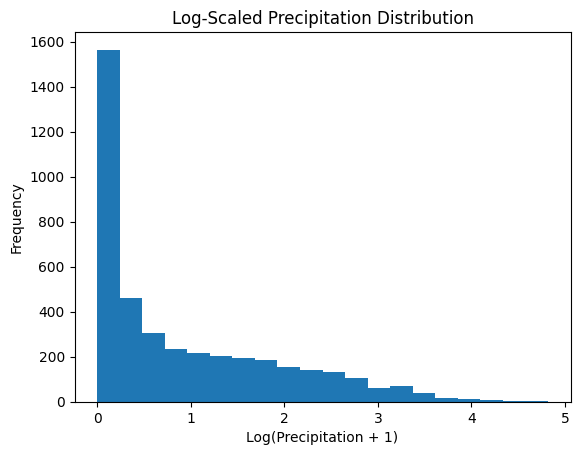

In [18]:
import numpy as np

plt.figure()
plt.hist(np.log1p(df["PRECTOTCORR"]), bins=20)
plt.title("Log-Scaled Precipitation Distribution")
plt.xlabel("Log(Precipitation + 1)")
plt.ylabel("Frequency")
plt.show()

### Precipitation Distribution Interpretation

The precipitation distribution is highly right-skewed, with most values concentrated near zero and a few extreme high values.
The logarithmic transformation highlights the presence of rare but intense rainfall events.
This reflects the irregular nature of precipitation, where heavy rainfall occurs infrequently.

## Multivariable Relationship Analysis

A bubble chart is used to examine the relationship between temperature (T2M) and relative humidity (RH2M), with precipitation represented by the size of the bubbles.

This visualization helps capture how multiple climate variables interact simultaneously, providing deeper insight into the conditions associated with rainfall events.

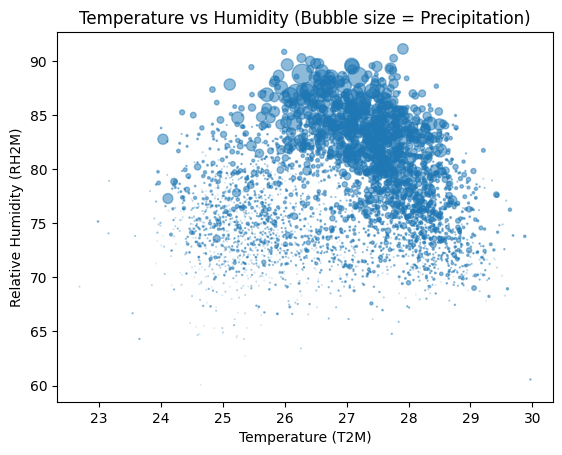

In [19]:
plt.figure()
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 2,  # scale bubbles
    alpha=0.5
)

plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("Temperature vs Humidity (Bubble size = Precipitation)")
plt.show()

### Bubble Chart Interpretation

The bubble chart shows a slight negative relationship between temperature and humidity.
Larger bubbles, representing higher precipitation, are concentrated in areas with high humidity and moderate temperatures.
This indicates that rainfall is primarily driven by moisture availability rather than temperature extremes.

## Key Insights

Tanzania exhibits a tropical climate with stable and moderate temperatures throughout the year.

Temperature variation is minimal, showing smooth and consistent seasonal patterns.

Rainfall follows a bimodal pattern, with two distinct rainy seasons (March–May and November–December).

Precipitation is highly variable, with frequent extreme rainfall events.

Humidity plays a key role in rainfall, while temperature has limited direct influence.

The climate alternates between clear wet and dry seasons, reflecting strong seasonal dynamics.